In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('hotel_bookings.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [165]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Проверим на дубликаты

In [166]:
df.duplicated().sum()

np.int64(31994)

Нашлось 31994 дубликатов. Очистим датасет от них

In [167]:
origin_shape0 = df.shape[0]
print(f'Количество строк до очистки от дубликатов: {origin_shape0}')
df = df.drop_duplicates()
print(f'Количество строк после удаления дубликатов: {df.shape[0]}. Дубликаты составляли {((origin_shape0 - df.shape[0]) / origin_shape0 * 100):.2f}% исходного датасета.')

Количество строк до очистки от дубликатов: 119390
Количество строк после удаления дубликатов: 87396. Дубликаты составляли 26.80% исходного датасета.


### Посмотрим каждый признак

#### Hotel

In [168]:
print(f'Пропусков у признака Hotel: {df['hotel'].isnull().sum()}')

Пропусков у признака Hotel: 0


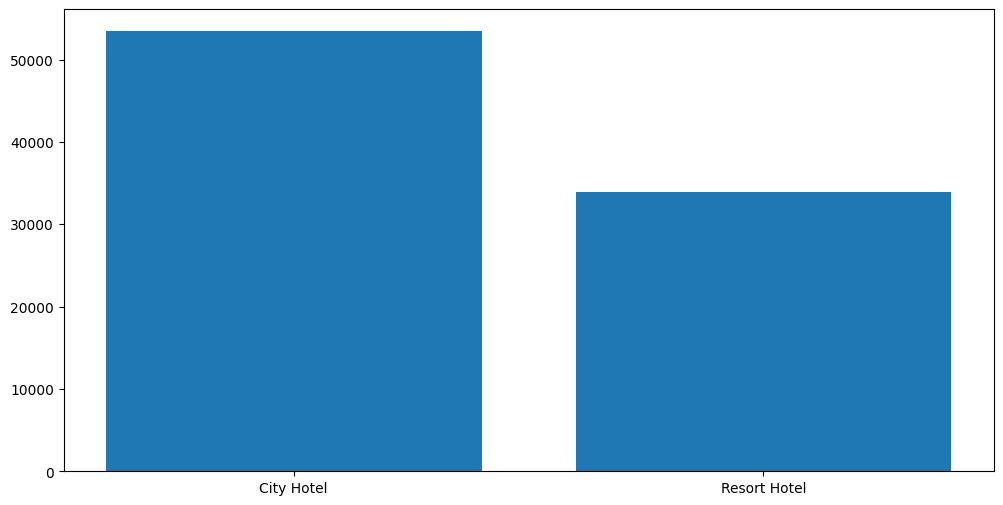

In [169]:

plt.figure(figsize=(12, 6))
plt.bar(df['hotel'].value_counts().index, df['hotel'].value_counts().values)
plt.show()

In [170]:
df['hotel'].value_counts() / df.shape[0] * 100

hotel
City Hotel      61.133233
Resort Hotel    38.866767
Name: count, dtype: float64

У нас всего два отеля: City Hotel - 61.13% и Resort Hotel - 38.87%. Пропусков нет. Можем предположить, что City Hotel более популярный в данном датасете - из-за меньшей привязки к сезонности, как, скорее всего, курортный отель - Resort Hotel. Но это будет рассмотрено уже в части анализа связи разных признаков.

#### is_canceled

In [171]:
print(f'Пропусков у признака is_canceled: {df['is_canceled'].isnull().sum()}')

Пропусков у признака is_canceled: 0


In [172]:
df['is_canceled'].value_counts() / df.shape[0] * 100

is_canceled
0    72.510184
1    27.489816
Name: count, dtype: float64

is_canceled - это основная целевая переменная - отменена ли бронь за отель. Мы видим дисбаланс классов, где не отменненых бронирований больше, но в реальности более высокое число успешных броней - нормально, почти 30% отмененных не так уж и мало.

#### lead_time

Это числовой признак, показывающий количество дней от даты внесения броня в базу, до дня прибытия 

In [173]:
print(f'Пропусков у признака lead_time: {df['lead_time'].isnull().sum()}')

Пропусков у признака lead_time: 0


/var/folders/7g/pl4qxcms0cl4_g77_lx6hrrm0000gn/T/ipykernel_81645/3919275564.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


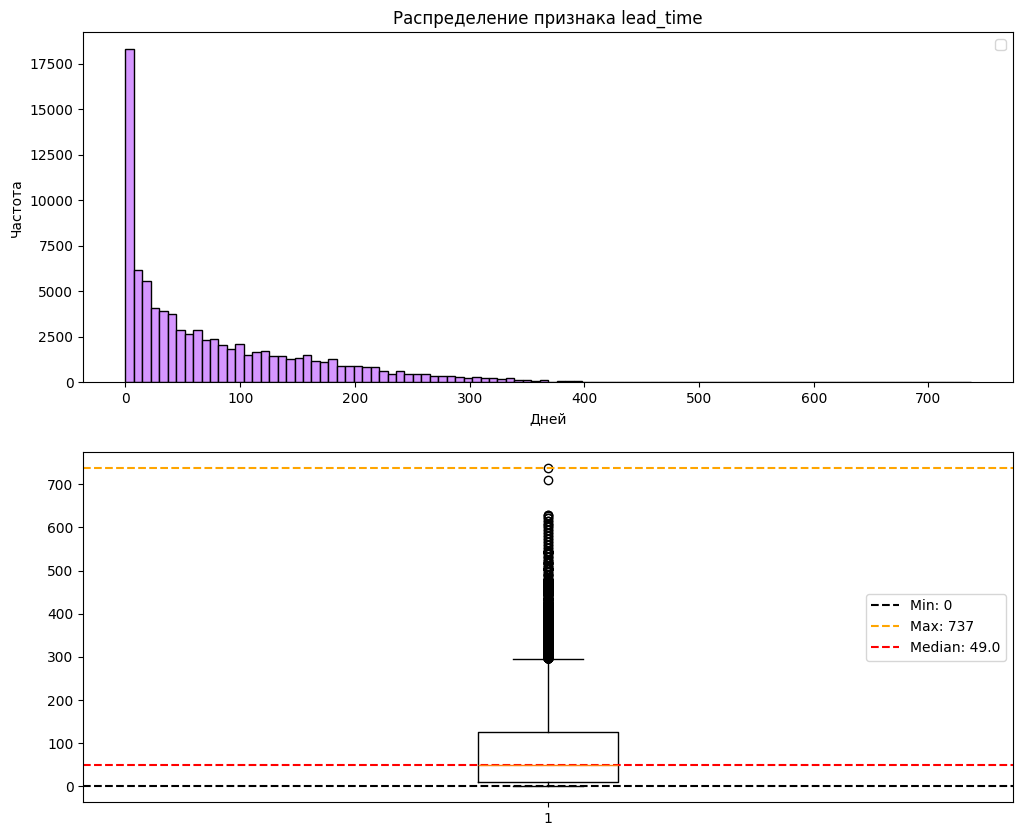

In [174]:
plt.figure(figsize=(12, 10))

plt.subplot(2,1,1)
plt.title('Распределение признака lead_time')
plt.hist(df['lead_time'], bins=100, edgecolor='black', color='#d596ff')
plt.xlabel('Дней')
plt.ylabel('Частота')
plt.legend()

plt.subplot(2,1,2)
plt.boxplot(df['lead_time'])
plt.axhline(df['lead_time'].min(), color='black', linestyle='--', label=f'Min: {df['lead_time'].min()}')
plt.axhline(df['lead_time'].max(), color='orange', linestyle='--', label=f'Max: {df['lead_time'].max()}')
plt.axhline(df['lead_time'].median(), color='red', linestyle='--', label=f'Median: {df['lead_time'].median()}')
plt.legend()
plt.show()

У нас довольно много значений в районе 0, посмотрим чуть ближе на более короткий отрезок

/var/folders/7g/pl4qxcms0cl4_g77_lx6hrrm0000gn/T/ipykernel_81645/36183028.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


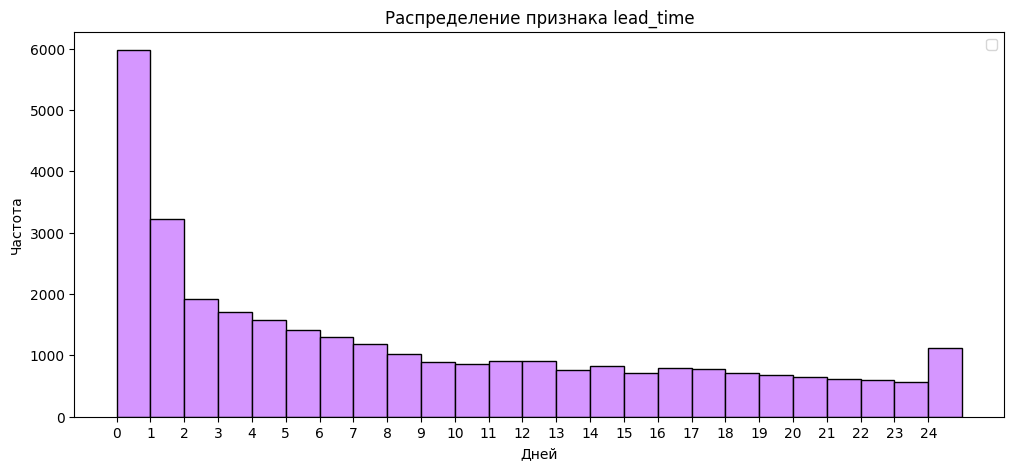

In [175]:
plt.figure(figsize=(12, 5))
plt.title('Распределение признака lead_time')
plt.hist(df[df['lead_time'] <= 25]['lead_time'], bins=25, edgecolor='black', color='#d596ff')
plt.xlabel('Дней')
plt.ylabel('Частота')
plt.xticks(range(0, 25))
plt.legend()

In [176]:
lead_time_25 = df[df['lead_time'] <= 25]['lead_time'].value_counts().reset_index()
lead_time_25['prc'] = lead_time_25['count'] / df.shape[0] * 100
lead_time_25

,lead_time,count,prc
0,0,5978,6.840130
1,1,3216,3.679802
2,2,1927,2.204906
3,3,1704,1.949746
4,4,1570,1.796421
5,5,1418,1.622500
6,6,1300,1.487482
7,7,1191,1.362763
8,8,1019,1.165957
9,12,915,1.046959


Большая часть - это бронирования сделанные, по всей видимости, в день заезда, то есть без брони заранее. Но при этом все равно чем меньше дней со дня брони до дня прибытия, то чем больше таких бронирований (по каждому дню отдельно). Посмотрим на две группы, разделив их неким порогом в 30 дней, то есть под "заранее забронировавших" возьмем тех, кто бронировал за месяц и более

In [177]:
under_30_lead_time = df[df['lead_time'] < 30]
more_30_lead_time = df[df['lead_time'] >= 30]

print(f'Доля бронирований в пределах месяца: {(under_30_lead_time.shape[0] / df.shape[0] * 100):.2f}%')
print(f'Доля бронирований за месяц и более: {(more_30_lead_time.shape[0] / df.shape[0] * 100):.2f}%')

Доля бронирований в пределах месяца: 39.03%
Доля бронирований за месяц и более: 60.97%


Хоть и рассматривая отдельное количество дней - 0, 1, 2 и т.д. дни популярнее, но, все равно, заранее бронируют чаще. Далее мы сможем выделить более подробные когорты, которые далее можно будет сравнивать по другим признакам.

#### Признаки, характеризирующие дату
Автор датасета выполнил вероятную часть нашей работы - детализировал дату на различные колонки (год, месяц, номер недели, день месяца). Посмотрим на них всех в одном блоке.

Проверим сразу все на дубликаты

In [178]:
print(f'Пропусков у признака arrival_date_year: {df['arrival_date_year'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_month: {df['arrival_date_month'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_week_number: {df['arrival_date_week_number'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_day_of_month: {df['arrival_date_day_of_month'].isnull().sum()}')

Пропусков у признака arrival_date_year: 0
Пропусков у признака arrival_date_month: 0
Пропусков у признака arrival_date_week_number: 0
Пропусков у признака arrival_date_day_of_month: 0


##### arrival_date_year
Год прибытия в отель

In [179]:
df['arrival_date_year'].value_counts() / df.shape[0] * 100

arrival_date_year
2016    48.504508
2017    36.262529
2015    15.232963
Name: count, dtype: float64

У нас представлены всего 3 года, с 2015 по 2017, где самым насыщенным является 2016, а менее насыщенными 2015 и 2017 - возможно, 2015 и 2017 года представлены не полные, но это мы посмотрим далее в части анализа связей признаков.

#### arrival_date_month
Месяц прибытия в отель

In [180]:
df['arrival_date_month'].sample(10)

57046    September
62565      January
78080      October
11425          May
55377       August
13405       August
21714        March
28348    September
31995      January
23218        April
Name: arrival_date_month, dtype: str

Месяца у нас представлены в формате названия месяца на английском, без указания года и прочего

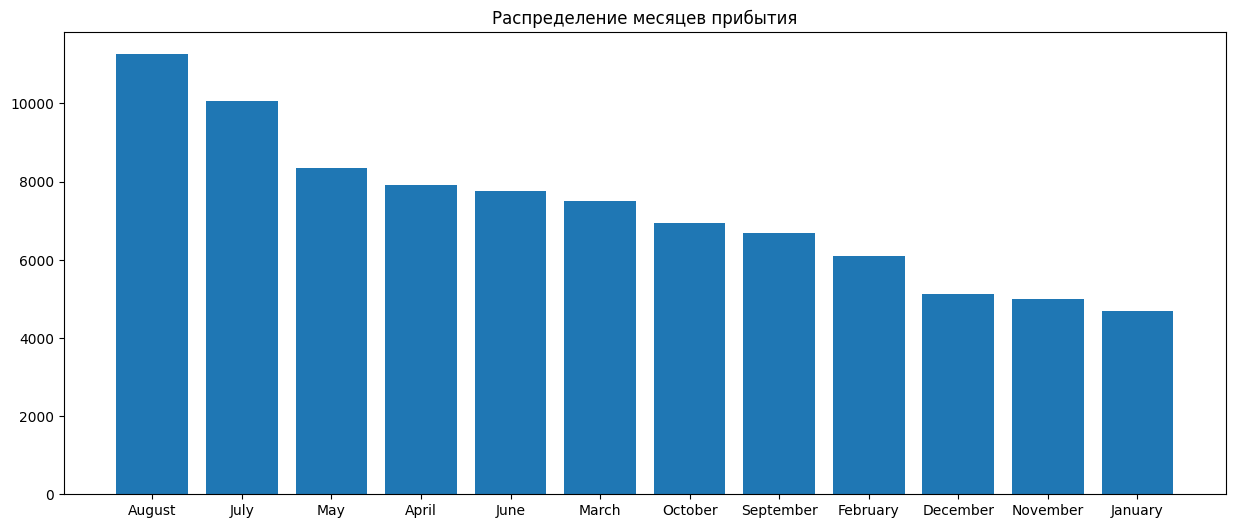

In [181]:
plt.figure(figsize=(15,6))
plt.title('Распределение месяцев прибытия')
plt.bar(df['arrival_date_month'].value_counts().index, df['arrival_date_month'].value_counts().values)
plt.show()

Самыми популярнымы оказались летние и вессение месяцы, возможно, из-за наличия Resort Hotel и в целом популярности туризма в более теплые времена года - они доминируют.

##### arrival_date_week_number
Номер недели прибытия

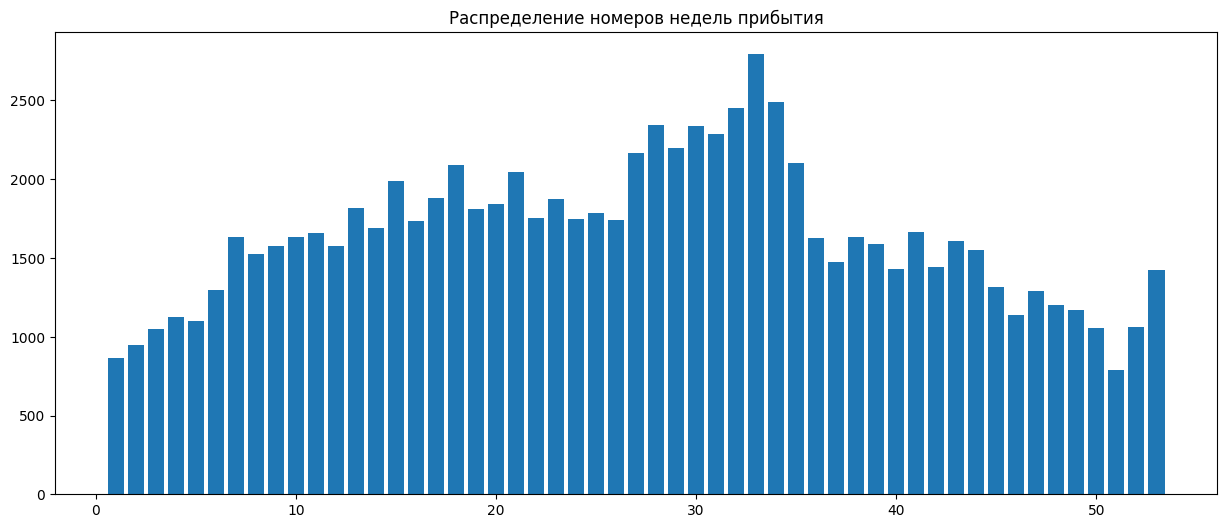

In [182]:
plt.figure(figsize=(15,6))
plt.title('Распределение номеров недель прибытия')
plt.bar(df['arrival_date_week_number'].value_counts().index, df['arrival_date_week_number'].value_counts().values)
plt.show()

 По этому графику также видно, что около 30-ой недели (июль-август) - как раз такая же доминация этих недель в летнее время, что было видно и на анализе месяцев. 

##### arrival_date_day_of_month
День прибытия

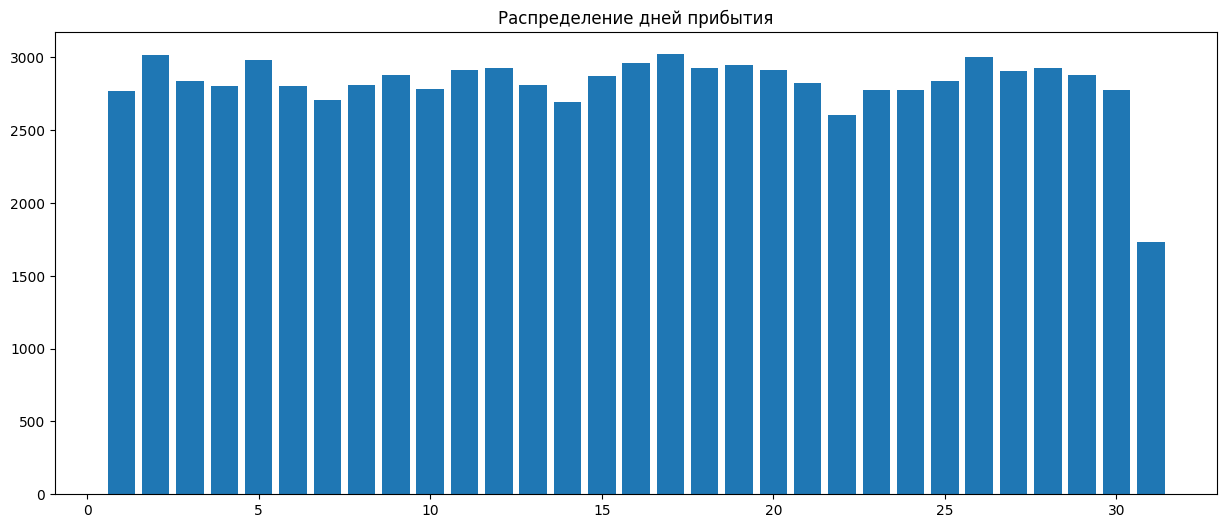

In [183]:
plt.figure(figsize=(15,6))
plt.title('Распределение дней прибытия')
plt.bar(df['arrival_date_day_of_month'].value_counts().index, df['arrival_date_day_of_month'].value_counts().values)
plt.show()

В целом во все дни примерно одинаковое количество прибытий, кроме 31 числа - таких месяцев просто меньше чем других

Следующие признаки также связы с датой, но теперь и заезда и выезда. При этом в датасете нет колонки с простой датой заезда и датой выезда. Возмиожно, так лучше, к примеру, для модели ML, но, скорее всего, нам придется вывести даты заезда и выезда самим. В любом случае посмотрим на следующие признаки.

#### stays_in_weekend_nights
Количество ночей выходных дней, в которые гости жили/бронировали

#### stays_in_week_nights
Количество ночей будних дней, в которые гости жили/бронировали

In [184]:
df['stays_in_weekend_nights'].value_counts()

stays_in_weekend_nights
0     35151
2     26414
1     22657
4      1734
3      1150
6       113
5        70
8        60
7        15
9        10
10        7
12        5
13        3
16        3
14        2
18        1
19        1
Name: count, dtype: int64

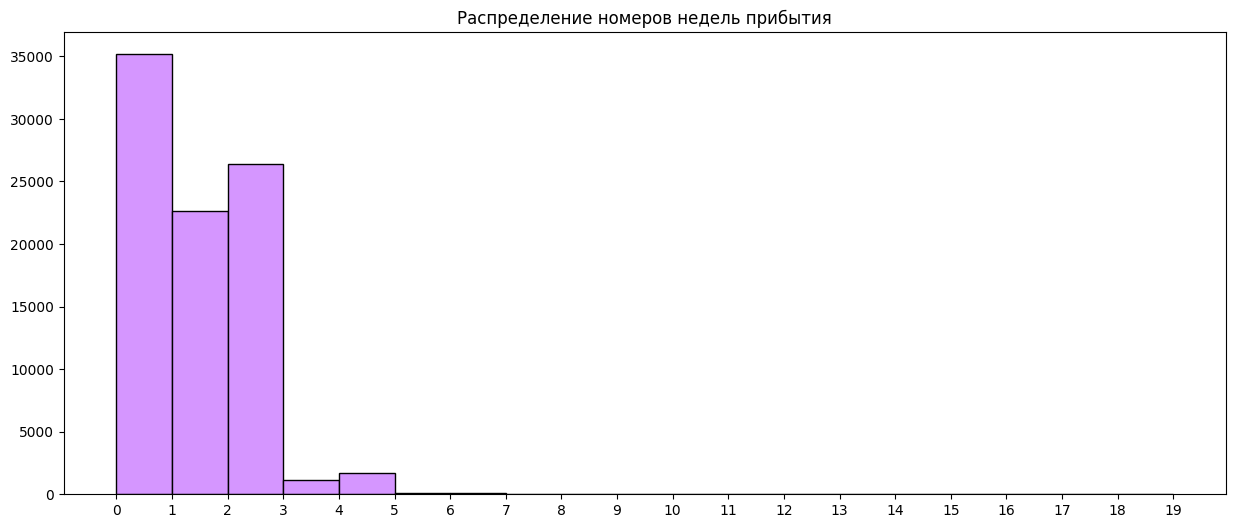

In [185]:
plt.figure(figsize=(15,6))
plt.title('Распределение номеров недель прибытия')
# plt.bar(df['stays_in_weekend_nights'].value_counts().index, df['stays_in_weekend_nights'].value_counts().values)
plt.hist(df['stays_in_weekend_nights'], bins=19, edgecolor='black', color='#d596ff')
plt.xticks(range(0, 20))
plt.show()

Большая часть бронирований, где 0-2 выходных было проведено в отеле, то есть большая часть их них были бронивания в пределах недели, при этом 2 выходных популярнее одного выходного - значит люди чаще остаются уже на оба выходных дня, либо же, что еще популярнее, просто приезжают в рабочую неделю.

In [186]:
df['stays_in_week_nights'].value_counts().sort_index()

stays_in_week_nights
0      6175
1     22191
2     20744
3     16259
4      7874
5      9663
6      1379
7       967
8       613
9       219
10      972
11       50
12       40
13       27
14       25
15       68
16       13
17        4
18        6
19       21
20       41
21       15
22        7
24        2
25        6
26        1
30        5
32        1
33        1
34        1
35        1
40        2
41        1
42        1
50        1
Name: count, dtype: int64

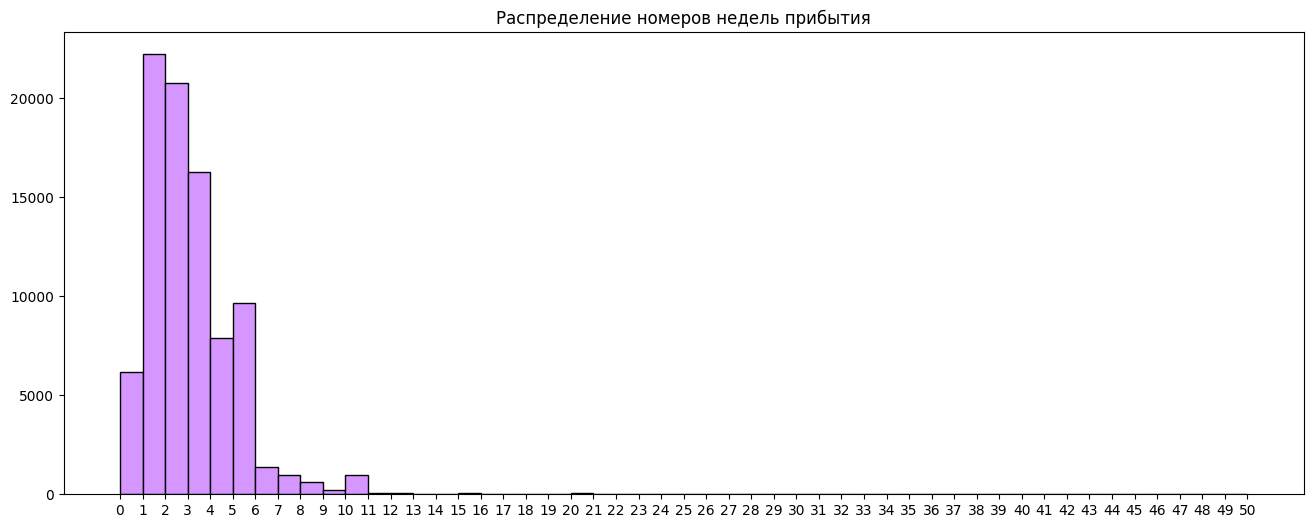

In [187]:
plt.figure(figsize=(16,6))
plt.title('Распределение номеров недель прибытия')
plt.hist(df['stays_in_week_nights'], bins=50, edgecolor='black', color='#d596ff')
plt.xticks(range(0, 51))
plt.show()

Здесь также видно, что большая часть бронирований в пределах недели, причем взяв во внимание крайне большие значения в обоих признаков - бывают бронирования очень долгие, надо будет еще далее посмотреть - это отмененные все бронирования или же они действительно были выполнены.

Сделующие признаки характеризуют состав гостей, а именно наличие взрослых, детей и младенцев
#### adults

In [188]:
print(f'Пропусков у признака adults: {df['adults'].isnull().sum()}')

Пропусков у признака adults: 0


In [189]:
df['adults'].value_counts().sort_index()

adults
0       385
1     16503
2     64497
3      5935
4        60
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

Чаще всего, что логично, приезжают парой, из интересного - бронирования по 10, 20 и даже по 50 и 55 человек - посмотрим их

In [190]:
df[df['adults'] >= 10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
1539,Resort Hotel,1,304,2015,September,36,3,0,3,40,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1587,Resort Hotel,1,333,2015,September,36,5,2,5,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1643,Resort Hotel,1,336,2015,September,37,7,1,2,50,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-18
1752,Resort Hotel,1,340,2015,September,37,12,2,5,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1884,Resort Hotel,1,347,2015,September,38,19,2,5,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1917,Resort Hotel,1,349,2015,September,39,21,1,3,27,0.0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1962,Resort Hotel,1,352,2015,September,39,24,1,3,27,0.0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
2003,Resort Hotel,1,354,2015,September,39,26,2,5,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
2164,Resort Hotel,1,361,2015,October,40,3,2,5,26,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
2173,Resort Hotel,1,338,2015,October,41,4,2,0,55,0.0,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02


Все бронирования тут это сентябрь - октябрь 2015. При этом почти все забронированы, скорее всего, одним человеком/тур агентством, где последнее изменение статуса - 2 января 2015, кроме пары исключений и все они в итоге отменены. Наверное кто-то либо так сильно ошибся, либо это были автоматические действия. 

Можем предположить, что если ни одно бронирование не было выполнено с числом взрослых от 10 и более, то эти странные бронирования есть смысл удалить, т.к. из-за ряда причин очень маловероятно, что все эти брони могли бы быть реализованы. Единственное, оставим брони, которые были сделаны не 2 января.

In [191]:
df = df[~((df['adults'] >= 10) & (df['reservation_status_date'] == '2015-01-02'))]

In [192]:
df[df['adults'] >= 10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
1643,Resort Hotel,1,336,2015,September,37,7,1,2,50,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-18
2228,Resort Hotel,1,328,2015,October,41,6,2,5,20,0.0,0,BB,PRT,Direct,Direct,0,0,0,D,D,1,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-09-03


#### children

In [193]:
print(f'Пропусков у признака children: {df['children'].isnull().sum()}')

Пропусков у признака children: 4


У нас нашлись 4 пропуска, посмотрим их

In [194]:
pd.options.display.max_columns = None # https://ru.hexlet.io/qna/data-analytics/questions/pandas-kak-vyvodit-vse-stolbtsy
df[df['children'].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


Во-первых видно два бронирования с общими датами, которые в итоге отменены, как и два других бронивания. Хотя и точь-в-точь по другим признаков они не одинаковые. Возможно, они были внесены в базу с ошибкой. Не будем выкидывать эти пропуски, а просто заполним нулем - самым популярным значением (будет видно ниже), предполоагая, что они собирались приехать без детей.

In [195]:
df['children'] = df['children'].fillna(0)
print(f'Пропусков у признака children: {df['children'].isnull().sum()}')

Пропусков у признака children: 0


In [196]:
pd.concat([df['children'].value_counts().sort_index(), df['children'].value_counts().sort_index() / df.shape[0] * 100], axis=1)

,count,count
children,,
0.0,79021,90.428563
1.0,4695,5.372776
2.0,3593,4.111690
3.0,75,0.085827
10.0,1,0.001144


Видно, что отели без семейного уклона, каким мог бы быть тот же Resort Hotel. 90% брониваний - без детей.

#### babies

In [197]:
print(f'Пропусков у признака babies: {df['babies'].isnull().sum()}')

Пропусков у признака babies: 0


In [198]:
pd.concat([df['babies'].value_counts().sort_index(), df['babies'].value_counts().sort_index() / df.shape[0] * 100], axis=1)

,count,count
babies,,
0,86471,98.954054
1,897,1.026492
2,15,0.017165
9,1,0.001144
10,1,0.001144


Почти 99% брониваний без младенцев, но есть два интересных случая, где в бронировании 9 и 10 младенцев. Посмотрим на эти 2 брони.

In [199]:
df[df['babies'] >= 9]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
46619,City Hotel,0,37,2016,January,3,12,0,2,2,0.0,10,BB,PRT,Online TA,TA/TO,0,0,0,D,D,1,No Deposit,9.0,NaN,0,Transient,84.45,0,1,Check-Out,2016-01-14
78656,City Hotel,0,11,2015,October,42,11,2,1,1,0.0,9,BB,GBR,Corporate,Corporate,0,0,0,A,B,1,No Deposit,95.0,NaN,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14


Эти две брони, на удивление, не отменены, причем одно из бронирований с 1 взрослым на 9 детей.

#### meal
Признак, указывающий на выбранный тип питания. Обратимся к описанию категорий с информации о датасете на kaggle:
- Undefined/SC – no meal package;
- BB – Bed & Breakfast;
- HB – Half board (breakfast and one other meal – usually dinner);
- FB – Full board (breakfast, lunch and dinner)

In [200]:
print(f'Пропусков у признака meal: {df['meal'].isnull().sum()}')

Пропусков у признака meal: 0


In [201]:
df['meal'].value_counts()

meal
BB           67970
SC            9481
HB            9082
Undefined      492
FB             360
Name: count, dtype: int64

Можем заметить, что Undefined и SC, судя по описанию - один и тот же вариант. Переименуем в таком случае Undefined на SC

In [202]:
df.loc[df['meal'] == 'Undefined', 'meal'] = 'SC'

In [203]:
df['meal'].value_counts()

meal
BB    67970
SC     9973
HB     9082
FB      360
Name: count, dtype: int64

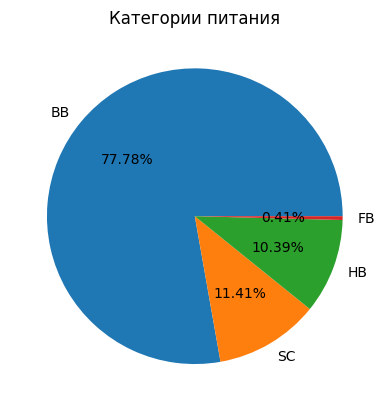

In [204]:
plt.figsize=(8, 6)

plt.title('Категории питания')
plt.pie(df['meal'].value_counts(), labels=df['meal'].value_counts().index, autopct='%.2f%%')

plt.show()

Большая часть бронирований - только завтраки. Бронирований с тремя приемами еды - вообще меньше процента

#### country
Этот признак - страна происхождения бронировавших. Судя по описанию на kaggle категории представлены в формате ISO 3155–3:2013, хотя загуглив его - ИИ от гугла в поиске говорит, что такого формата нет и, возможно, имелось в виду ISO 3166-3. Но посмотрим еще далее, для начала проверим наличие пропусков.

In [205]:
print(f'Пропусков у признака country: {df['country'].isnull().sum()}')

Пропусков у признака country: 452


У нас достаточно много пропусков в country. Выведем рандомные 10

In [206]:
df[df['country'].isna()].sample(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14542,Resort Hotel,0,2,2015,December,51,17,0,2,2,0.0,0,BB,NaN,Direct,Direct,0,0,1,A,D,0,No Deposit,NaN,NaN,0,Transient,43.00,0,1,Check-Out,2015-12-19
14215,Resort Hotel,0,26,2015,October,44,27,0,1,1,0.0,0,BB,NaN,Corporate,Corporate,0,0,2,A,D,0,No Deposit,NaN,113.0,0,Transient,48.00,0,0,Check-Out,2015-10-28
14531,Resort Hotel,0,2,2017,March,13,30,0,1,1,0.0,0,BB,NaN,Corporate,Corporate,0,0,3,A,A,0,No Deposit,NaN,135.0,0,Transient,35.00,1,0,Check-Out,2017-03-31
14038,Resort Hotel,0,126,2016,July,28,5,19,50,1,0.0,0,HB,NaN,Direct,Direct,0,0,1,E,E,2,No Deposit,NaN,NaN,0,Transient,110.00,0,3,Check-Out,2016-09-12
14192,Resort Hotel,1,160,2017,April,14,2,2,3,2,0.0,0,BB,NaN,Direct,Direct,0,1,4,E,E,0,No Deposit,NaN,NaN,0,Transient,70.80,0,3,Canceled,2017-03-20
14191,Resort Hotel,0,66,2016,October,42,9,2,3,2,0.0,0,BB,NaN,Direct,Direct,0,0,3,E,E,0,No Deposit,NaN,NaN,0,Transient,66.00,1,3,Check-Out,2016-10-14
14087,Resort Hotel,0,165,2016,August,33,13,2,6,2,0.0,0,BB,NaN,Offline TA/TO,TA/TO,0,0,0,E,E,0,No Deposit,181.0,NaN,0,Transient,138.00,1,0,Check-Out,2016-08-21
14591,Resort Hotel,0,14,2015,July,28,6,1,4,2,0.0,0,BB,NaN,Offline TA/TO,TA/TO,0,0,0,A,C,0,No Deposit,175.0,NaN,0,Transient,58.95,0,0,Check-Out,2015-07-11
14366,Resort Hotel,0,1,2016,April,18,24,1,0,2,0.0,0,BB,NaN,Corporate,Corporate,0,0,3,A,A,0,No Deposit,NaN,NaN,0,Transient,71.00,1,0,Check-Out,2016-04-25
14207,Resort Hotel,0,6,2016,January,2,5,0,2,1,0.0,0,BB,NaN,Online TA,TA/TO,0,0,1,A,D,0,No Deposit,240.0,NaN,0,Transient,39.00,0,2,Check-Out,2016-01-07


Пока подумаем, что с ними сделать. Пока посмотрим как в итоге выглядят обозначения стран.

In [207]:
df['country'].value_counts()[0:10]

country
PRT    27442
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

Здесь мы видим трехбуквенные (самые распространенные) обозначения стран (хотя этот ISO 3155–3:2013 - четырехбуквенные, причем стран, которых уже не существует, как к примеру - СССР это будет SUHH). Скорее всего еще одна ошибочка в описании и это на деле ISO 3166-1. Посмотрим на соотношение топ 5 категорий и остальных, при этом в более понятный вид расшифруем эти 5 стран:
- PRT - Португалия
- GBR - Великобритания
- FRA - Франция
- ESP - Испания
- DEU - Германия

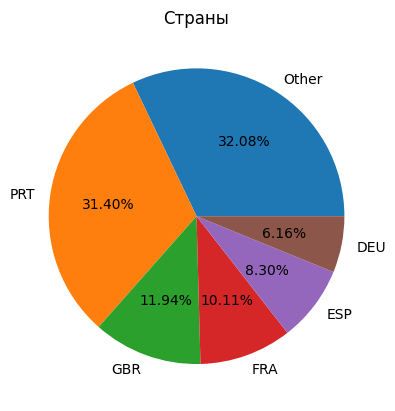

In [208]:
plt.figsize=(8, 6)

df_changed_countries = df.copy()
df_changed_countries.loc[~df['country'].isin(['PRT', 'GBR', 'FRA', 'ESP', 'DEU']), 'country'] = 'Other'

plt.title('Страны')
plt.pie(df_changed_countries['country'].value_counts(), labels=df_changed_countries['country'].value_counts().index, autopct='%.2f%%')

plt.show()

Можем заметить, что большая часть у нас из Португалии - почти треть выборки. Далее еще ряд крупных европейских государств. Можем предположить, что отель находится в Португалии - из-за чего и число бронирований оттуда наибольшее.

И давайте заполним пропуски самой популярной - Португалией.

In [209]:
df['country'] = df['country'].fillna('PRT')
print(f'Пропусков у признака country: {df['country'].isnull().sum()}')

Пропусков у признака country: 0


#### market_segment
Обозначение сегмента рынка. Описание на kaggle говорит, только о паре расшифровок: “TA” - “Турагенства", “TO” это “Туроператоры", остальное посмотрим сами.

Перед этим, как и везде, проверим признак на наличие пропусков.

In [210]:
print(f'Пропусков у признака market_segment: {df['market_segment'].isnull().sum()}')

Пропусков у признака market_segment: 0


In [211]:
df['market_segment'].value_counts()

market_segment
Online TA        51618
Offline TA/TO    13884
Direct           11798
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

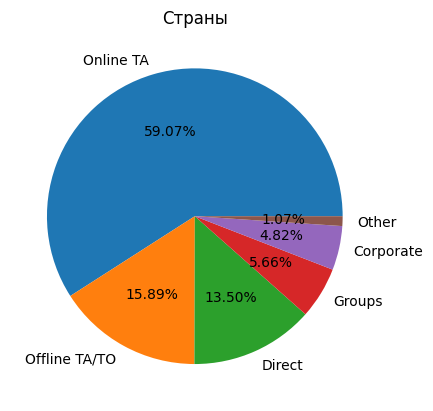

In [212]:
plt.figsize=(8, 6)

df_changed_market_segment = df.copy()
df_changed_market_segment.loc[~df['market_segment'].isin(['Online TA', 'Offline TA/TO', 'Direct', 'Groups', 'Corporate']), 'market_segment'] = 'Other'

plt.title('Страны')
plt.pie(df_changed_market_segment['market_segment'].value_counts(), labels=df_changed_market_segment['market_segment'].value_counts().index, autopct='%.2f%%')

plt.show()

Популярнее всех - онлайн и оффлайн турагенства и, для оффлайна, еще напрямую туроператоры, далее Direct - видимо прямые брони, и более менее долю еще занимают Groups - группы и Corporate - корпоративные. В целом распределение логичное, ничего аномального. Есть правда еще два бронирования с фактически пропуском, просто заполненным значением Undefined. Можем объединение в Other, которое мы брали для графика - сохранить в сам датасет, туда же попадет undefined и прочие малочисленные категории, которые вряд ли можно по отдельно рассмотреть из-за их размера.

In [213]:
df.loc[~df['market_segment'].isin(['Online TA', 'Offline TA/TO', 'Direct', 'Groups', 'Corporate']), 'market_segment'] = 'Other'

#### distribution_channel
Этот признак - канал распространения бронирования, в описании на kaggle там также добавлено про расшифровку TO и TA - что намекает нам на похожие категории, что и в прошлом признаке.

In [214]:
print(f'Пропусков у признака distribution_channel: {df['distribution_channel'].isnull().sum()}')

Пропусков у признака distribution_channel: 0


In [215]:
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        69136
Direct       12982
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64

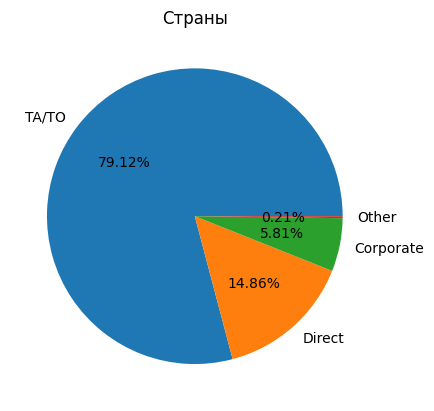

In [216]:
plt.figsize=(8, 6)

df_changed_distribution_channel = df.copy()
df_changed_distribution_channel.loc[~df['distribution_channel'].isin(['TA/TO', 'Direct', 'Corporate']), 'distribution_channel'] = 'Other'

plt.title('Страны')
plt.pie(df_changed_distribution_channel['distribution_channel'].value_counts(), labels=df_changed_distribution_channel['distribution_channel'].value_counts().index, autopct='%.2f%%')

plt.show()

Можно заметить действильно схожесть с прошлым признаком. Если мы объединим число бронированием с сегментам 'Online TA', 'Offline TA/TO', 'Groups', то выйдет около 80,62% и здесь у нас TA/TO 79.12% - просто добавились туда еще группы, которые логично, что оформлялись через какого-то тур оператора. Доля Dircet и Corporate также примерно одинаковые. Давайте также все остальное заменим на Other.

In [217]:
df.loc[~df['distribution_channel'].isin(['TA/TO', 'Direct', 'Corporate']), 'distribution_channel'] = 'Other'

### Итог по первым 16 признакам

- **hotel** - две больших группы, которые мы далее сможем сравнивать между собой (два указанных отеля)

- **is_canceled** - таргет, основной признак показывающий успех/неуспех бронирования и важен для бизнеса, так что он точно будет рассмотрен далее и будет завязан в гипотезах далее.

- **lead_time** - этот признак может оказаться полезным как определяющий заранее лида, то есть далее сможем посмотреть, связано ли более раннее бронирование с успехом или наоброт. Или, как было предложено при рассмотрении признака, выделим различные варианты когорт и сравним их.

- **arrival_date_year**, **arrival_date_month**, **arrival_date_week_number**, **arrival_date_day_of_month** - это декомпозиция даты приезда, причем ее в классическом виде в датасете нет. Скорее всего, прям полная дата как отдельный признак нам и не нужен, скорее нужно будет делить на когороты по месяцам, году, в частности смотреть на год + месяц.

- **stays_in_weekend_nights**, **stays_in_week_nights** - здесь уже скорее производные от даты выселения, то есть через эти признаки и те что выше - можно вычислить дату предполагаемого выселения. Разве что для успешных бронирований, кто сохранилось время установки статуса Check-Out - можно понять дату выезда по ней, но для отменных также не получится. Возможно, проще будет сделать колонку - количество ночей + бинарный признак - были ли выходные ночи.

- **adults**, **children**, **babies** - характер проживающих в отелях, где далее может быть логичнее выделить из всех них категории по типу: "Solo", "Couple", "With children" и т.п., так мы объединим эти признаки в один, выделим логичные категории, которые будет резоннее сравнивать между собой.

- **meal** - почти везде мы наблюдали классический вариант только с завтраками, где все остальное редкие случаи, так что этот признак вряд ли будет очень полезен в рамках нашего анализа.    

- **country** - логично далее страны также объединить по какому-то признаку, к примеру, по региону: Европа, Азия, Африка и т.д. Возможно, мы увидим какие-то различия между этими группами.

- **market_segment**, **distribution_channel** - не очень ясно по итогу глобально чем отличаются признаки, просто разве что будто бы в market_segment больше детализации внутри самых популярных групп. Скорее потом оставим какой-то один и будем сравнивать, к примеру, бронирования через тур операторов/тур агентов и прямые. 

### Далее перейдем к Feature Engineering с этими признакми

Выбросим признак meal

In [218]:
df = df.drop(columns={'meal'})

Выделим категории гостей исходя из данных признаков adults, children, babies

- Solo - один взрослый
- Couple - два взрослых
- With kids - взрослые с детьми
- Group - группа взрослых
- Only kids - только дети

In [219]:
df['kids'] = df['children'] + df['babies']

def guests_categories(x):
    if x['kids'] == 0 and x['adults'] == 1:
        return 'Solo'
    elif x['kids'] == 0 and x['adults'] == 2:
        return 'Couple'
    elif x['kids'] > 0 and x['adults'] > 0:
        return 'With kids'
    elif x['kids'] == 0 and x['adults'] > 2:
        return 'Group'
    elif x['kids'] > 0 and x['adults'] == 0:
        return 'Only kids'
    
df['guests_categories'] = df.apply(guests_categories, axis=1)
pd.concat([df['guests_categories'].value_counts(), df['guests_categories'].value_counts() / df.shape[0] * 100], axis=1)

,count,count
guests_categories,,
Couple,56582,64.750243
Solo,16068,18.387595
With kids,8884,10.166505
Group,5466,6.255078
Only kids,219,0.250615


Заметим, что большая часть гостей - это пары по два человека, при этом были случаи и бронирований исключительно с детьми. Старые колонки удалим.

In [220]:
df = df.drop(columns={'adults', 'kids', 'children', 'babies'})

Сделаем новые колонки с общим количеством ночей и наличием выходных ночей

In [221]:
df['stays_in_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [222]:
df['has_weekend_nights'] = 0
df.loc[df['stays_in_weekend_nights'] > 0, 'has_weekend_nights'] = 1

In [223]:
df = df.drop(columns={'stays_in_week_nights', 'stays_in_weekend_nights'})

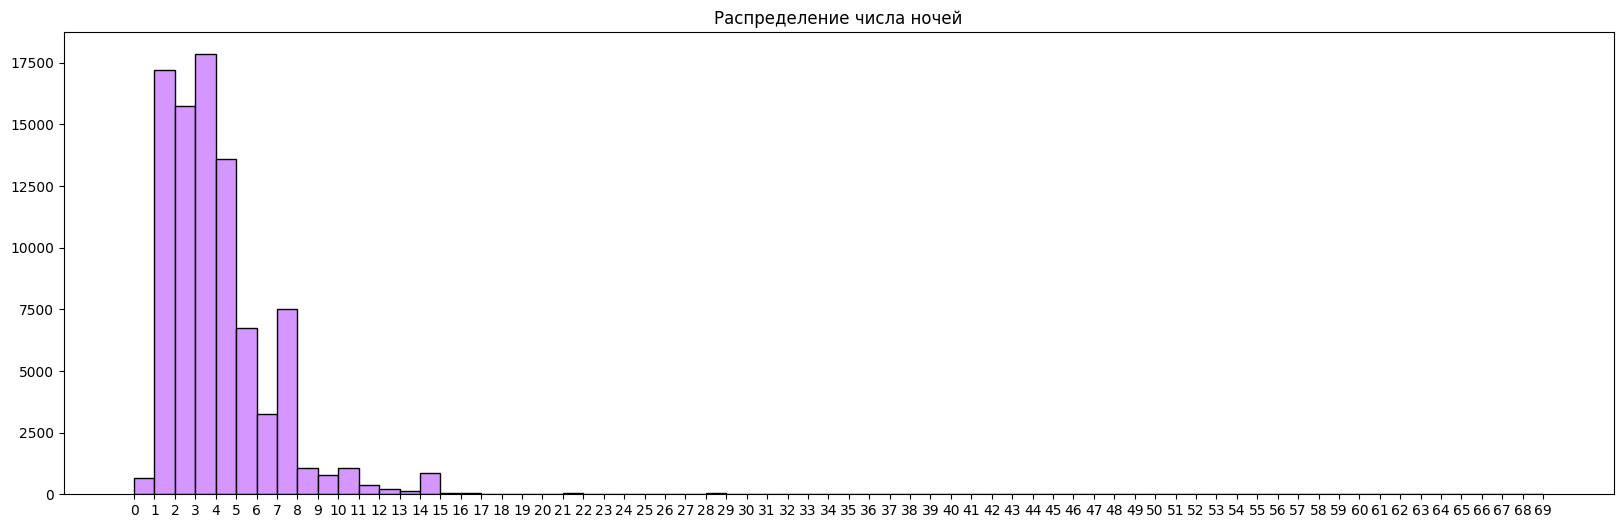

In [224]:
plt.figure(figsize=(20,6))
plt.title('Распределение числа ночей')
plt.hist(df['stays_in_nights'], bins=df['stays_in_nights'].max(), edgecolor='black', color='#d596ff')
plt.xticks(range(0, df['stays_in_nights'].max() + 1))
plt.show()

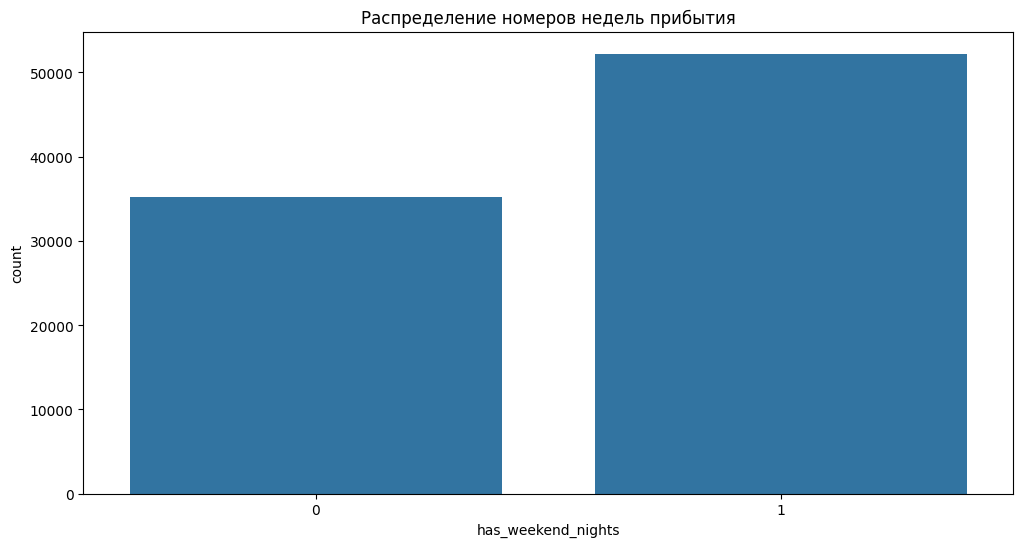

In [225]:
plt.figure(figsize=(12,6))
plt.title('Распределение номеров недель прибытия')
sns.barplot(df['has_weekend_nights'].value_counts())
plt.show()

Больше бронирований с наличием выходных, но и чисто в будние дни их немало.

## Перейдем к multivariate analysis по данным признакам

### hotel & is_cancelled
Базовое сравнение отелей по успешности, измеряемой таргетом.

In [226]:
df[df['hotel'] == 'City Hotel']['is_canceled'].value_counts()

is_canceled
0    37379
1    16049
Name: count, dtype: int64

In [227]:
city_hotel_canceled_cnt = round(df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 1)].shape[0] / df[df['hotel'] == 'City Hotel'].shape[0] * 100, 2)

In [228]:
resort_hotel_canceled_cnt = round(df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 1)].shape[0] / df[df['hotel'] == 'Resort Hotel'].shape[0] * 100, 2)

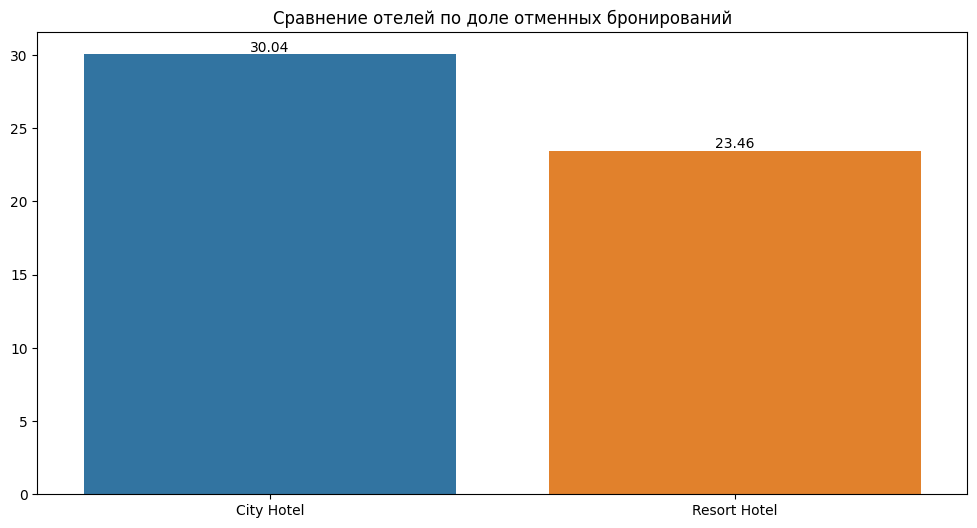

In [229]:
plt.figure(figsize=(12,6))
plt.title('Сравнение отелей по доле отменных бронирований')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot
ax = sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}))
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

В City Hotel доля отмененных бронирований больше, 30% против 23.5%. То есть на первый взгляд Resort Hotel показывает себя лучше, но мы еще далее посмотрим сравнение этих отелей вкупе с другими признаками.

### guests_categories & is_canceled

Посмотрим на то, есть ли различия между разными типами гостей и таргетом

In [230]:
guests_categories = df.groupby('guests_categories').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

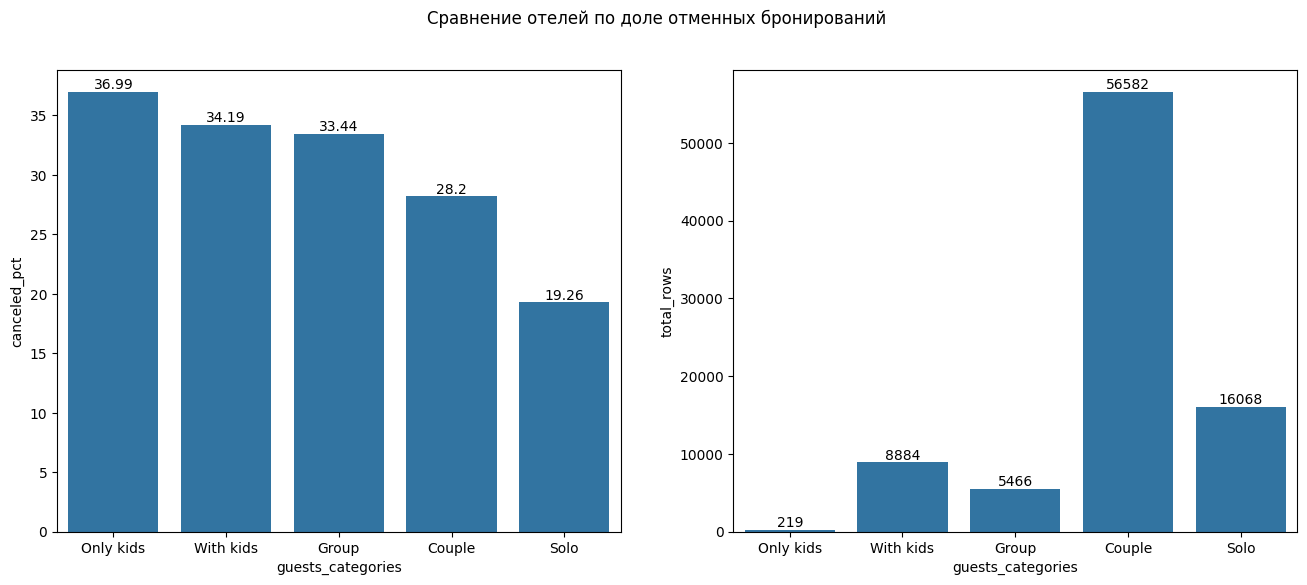

In [231]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение отелей по доле отменных бронирований')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне
sns.barplot(guests_categories['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(guests_categories['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

Можно заметить, что самая высокая доля отмен у броней только с детьми в виде гостей, но их и самое малое количество. Интереснее тут группы: 1) с одним гостем и 2) гости с детьми. Сольные брони у нас самые успешные по таргету, а с детьми самые неуспешные, не считая очень маленькой "странной" группы - только дети. При этом размеры выборок обе сильно меньше самой популярной группы - пары и между собой не так сильно различимы, хоть и разница примерно в 2 раза по размерам. Так что эту гипотезу можно далее проверить статистически - действительно ли брони с детьми "хуже" сольных бронирований.

### Объединим два наблюдения выше. Посмотрим также сравнение категорий гостей, но дополнительно сравним разные отели

In [232]:
guests_categories = df.groupby(['guests_categories', 'hotel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

In [233]:
guests_categories

total_canceled  total_rows  canceled_pct
guests_categories hotel                                                 
Only kids         City Hotel                81         219         36.99
Group             City Hotel              1643        4452         36.90
With kids         Resort Hotel            1364        3869         35.25
                  City Hotel              1673        5015         33.36
Couple            City Hotel             10376       33413         31.05
                  Resort Hotel            5582       23169         24.09
Solo              City Hotel              2262       10175         22.23
Group             Resort Hotel             185        1014         18.24
Solo              Resort Hotel             832        5893         14.12

In [234]:
hotels_value_counts = df['hotel'].value_counts().reset_index().T
# https://datascientyst.com/how-to-use-the-first-row-as-the-header-in-pandas/
hotels_value_counts.columns = hotels_value_counts.iloc[0]
hotels_value_counts = hotels_value_counts[1:]

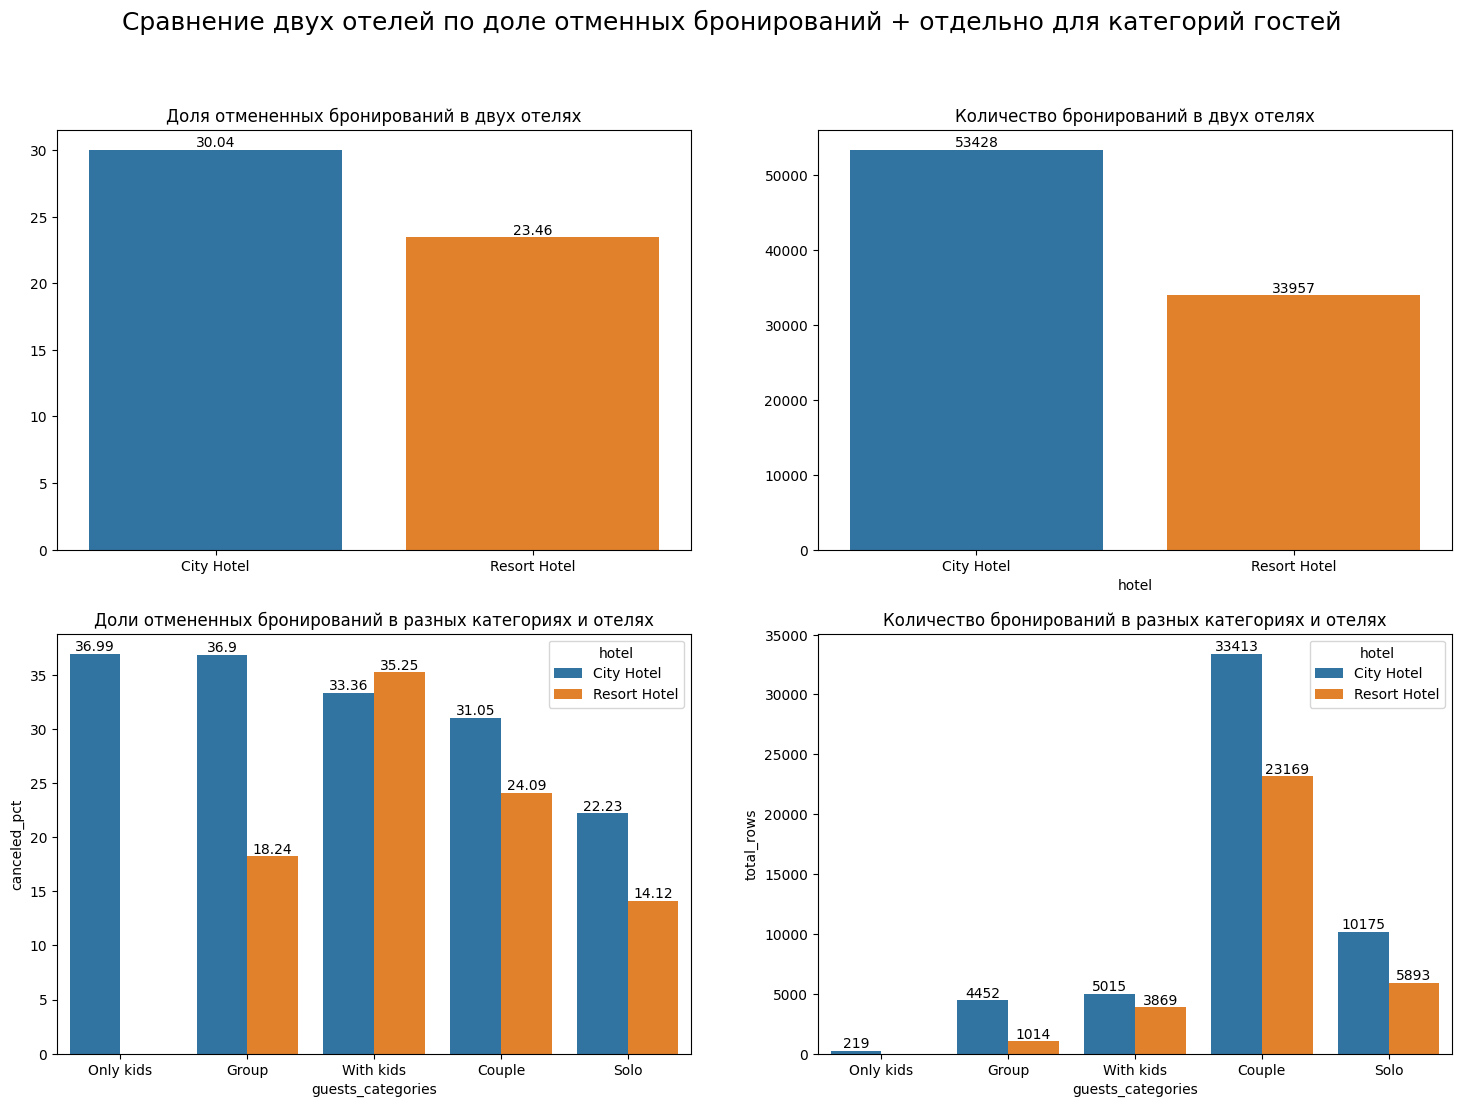

In [235]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle('Сравнение двух отелей по доле отменных бронирований + отдельно для категорий гостей', fontsize='18')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне

sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}), ax=axes[0, 0])
axes[0, 0].set_title('Доля отмененных бронирований в двух отелях')
axes[0, 0].bar_label(axes[0, 0].containers[0])
axes[0, 0].bar_label(axes[0, 0].containers[1])

sns.barplot(hotels_value_counts, ax=axes[0, 1])
axes[0, 1].set_title('Количество бронирований в двух отелях')
axes[0, 1].bar_label(axes[0, 1].containers[0])
axes[0, 1].bar_label(axes[0, 1].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='canceled_pct', hue='hotel', ax=axes[1, 0])
axes[1, 0].set_title('Доли отмененных бронирований в разных категориях и отелях')
axes[1, 0].bar_label(axes[1, 0].containers[0])
axes[1, 0].bar_label(axes[1, 0].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='total_rows', hue='hotel', ax=axes[1, 1])
axes[1, 1].set_title('Количество бронирований в разных категориях и отелях')
axes[1, 1].bar_label(axes[1, 1].containers[0])
axes[1, 1].bar_label(axes[1, 1].containers[1])
plt.show()

Тут добавилось интересное дополнение - категория With kids в обоих отелях примерно с одинаковой долей отмененных броней и с несильно отличающейся выборкой в каждом из отелей, а вот если смотреть на Solo, то в Resort Hotel она показывает себя еще лучше с процентом отмен всего в 14.12%, но бронирований там почти в 2 раза меньше чем в City Hotel. Отсюда выходит еще одна возможная гипотеза о том, что Solo успешнее, причем в одном из отелей, который в целом по всем категориям показывает себя лучше - это еще заметнее и тогда сравнение этих категорий в рамках Resort Hotel, возможно, покажет еще большую уверенность и саму разность групп. Анализ всего этого блока может в итоге дать хорошее наблюдение для отеля - а именно то, какие категории гостей надежнее и в каких отелях это проявляется особенно хорошо или же один отель просто в целом лучше другого и разница между категориями внутри отелей примерно одинаковая. Далее надо подумать над тем, какие гипотезы сформировать лучше всего для получения наиболее полезного результата для бизнеса.

#### guests_categories & (market_segment, distribution_channel)
Посмотрим на то, как об отеле узнают, как бронируют разные категории гостей. Только в этот раз не будем смотреть категории Only kids чтобы не перезагружать полученный "дашборд".

In [237]:
market_segment_in_guests_categories = df.groupby(['guests_categories', 'market_segment']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size')).reset_index()
market_segment_in_guests_categories['canceled_pct'] = round(market_segment_in_guests_categories['total_canceled'] / market_segment_in_guests_categories['total_rows'] * 100, 2)

distribution_channel_in_guests_categories = df.groupby(['guests_categories', 'distribution_channel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size')).reset_index()
distribution_channel_in_guests_categories['canceled_pct'] = round(distribution_channel_in_guests_categories['total_canceled'] / distribution_channel_in_guests_categories['total_rows'] * 100, 2)

distribution_channel_in_guests_categories


,guests_categories,distribution_channel,total_canceled,total_rows,canceled_pct
0,Couple,Corporate,227,1157,19.62
1,Couple,Direct,1181,7845,15.05
2,Couple,Other,8,17,47.06
3,Couple,TA/TO,14542,47563,30.57
4,Group,Corporate,9,61,14.75
5,Group,Direct,93,612,15.20
6,Group,Other,2,2,100.00
7,Group,TA/TO,1724,4791,35.98
8,Only kids,Direct,8,33,24.24
9,Only kids,TA/TO,73,186,39.25


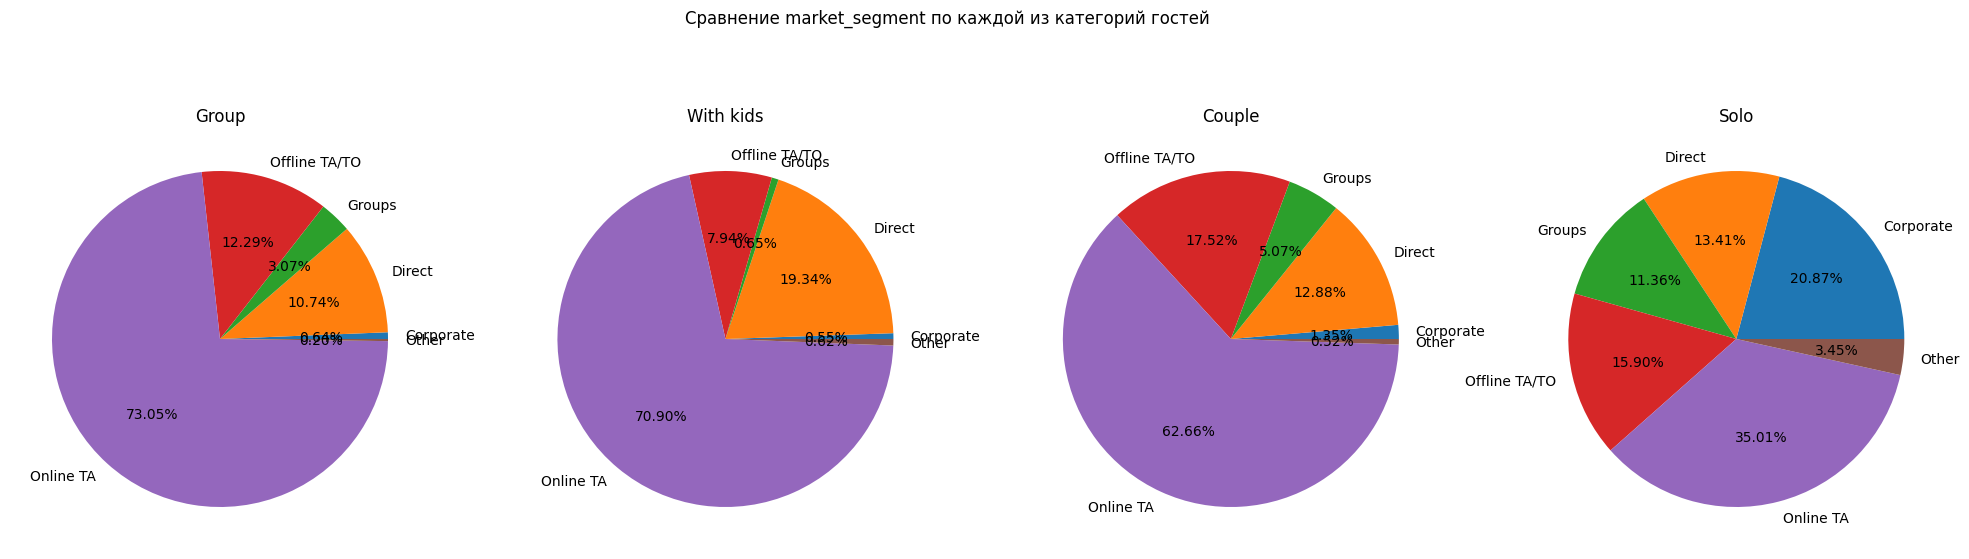

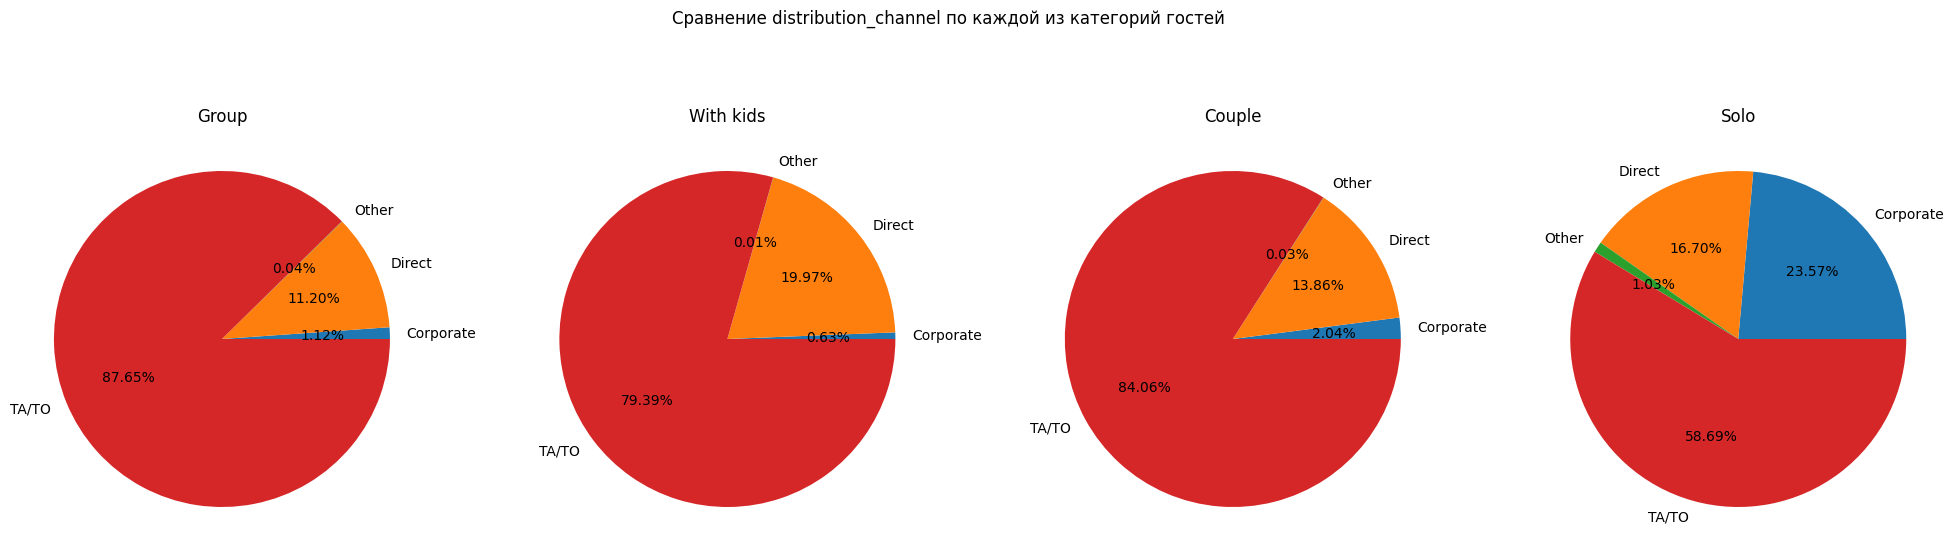

In [238]:
plt.figure(figsize=(25, 12))

plt.suptitle('Сравнение market_segment по каждой из категорий гостей')
plt.subplot(2, 4, 1)

plt.title('Group')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Group']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 2)

plt.title('With kids')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'With kids']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 3)

plt.title('Couple')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Couple']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 4)

plt.title('Solo')
plt.pie(market_segment_in_guests_categories[market_segment_in_guests_categories['guests_categories'] == 'Solo']['total_rows'], labels=market_segment_in_guests_categories['market_segment'].unique(), autopct='%.2f%%')

plt.show()

plt.figure(figsize=(25, 12))

plt.suptitle('Сравнение distribution_channel по каждой из категорий гостей')
plt.subplot(2, 4, 1)

plt.title('Group')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Group']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 2)

plt.title('With kids')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'With kids']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 3)

plt.title('Couple')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Couple']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.subplot(2, 4, 4)

plt.title('Solo')
plt.pie(distribution_channel_in_guests_categories[distribution_channel_in_guests_categories['guests_categories'] == 'Solo']['total_rows'], labels=distribution_channel_in_guests_categories['distribution_channel'].unique(), autopct='%.2f%%')

plt.show()

Можно заметить, что во всех категориях кроме Solo большая часть бронирований оформляется через тур агентов и тур операторов, причем зачастую онлайн. Но вот у Solo заметно увеличение как категории Corporate, что как будто говорит о том, что это оформляются командировочные для сотрудников, так и Groups, что как будто также говорит о том, что это те же командировки, но групповые. Это предположительно может объяснять низкую долю отмен бронирований, но для этого давайте далее сравним Corporate с другими (возьмем самые основные: TO/TA и Direct) по таргету is_canceled. Пока продолжим смотреть по обоим признакам и по market_segment и по distribution_channel. 

In [239]:
market_segments = df.groupby('market_segment').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))
market_segments['canceled_pct'] = round(market_segments['total_canceled'] / market_segments['total_rows'] * 100, 2)
market_segments = market_segments[market_segments.index != 'Other']

distribution_channels = df.groupby('distribution_channel').agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))
distribution_channels['canceled_pct'] = round(distribution_channels['total_canceled'] / distribution_channels['total_rows'] * 100, 2)
distribution_channels = distribution_channels[distribution_channels.index != 'Other']

distribution_channels


,total_canceled,total_rows,canceled_pct
distribution_channel,,,
Corporate,648,5081,12.75
Direct,1919,12982,14.78
TA/TO,21407,69136,30.96


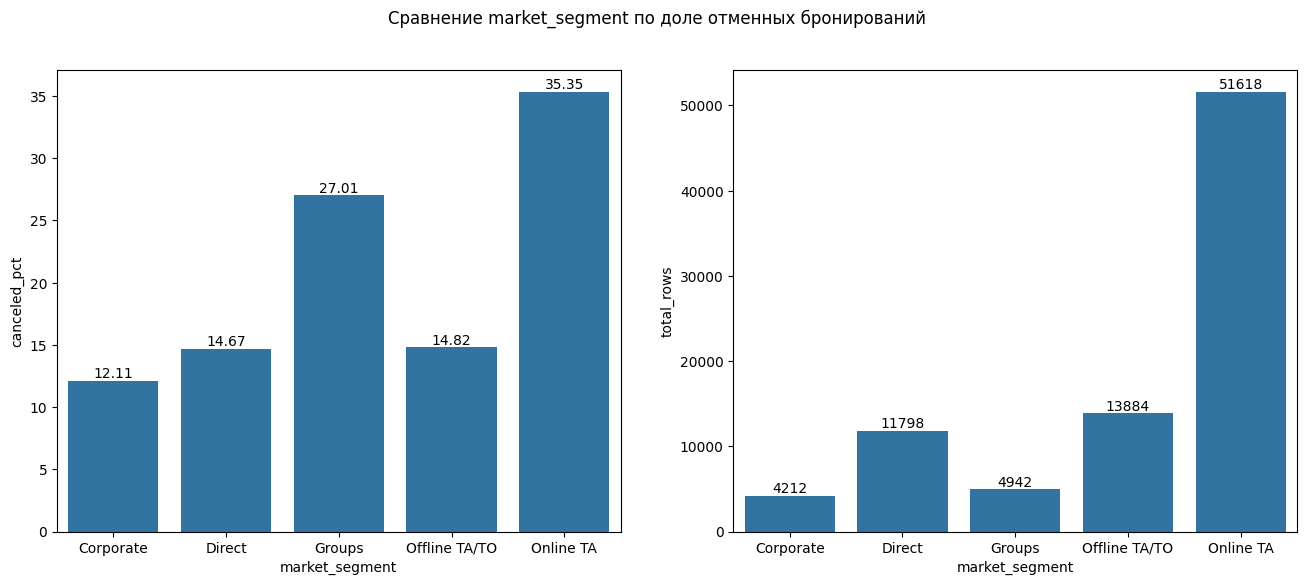

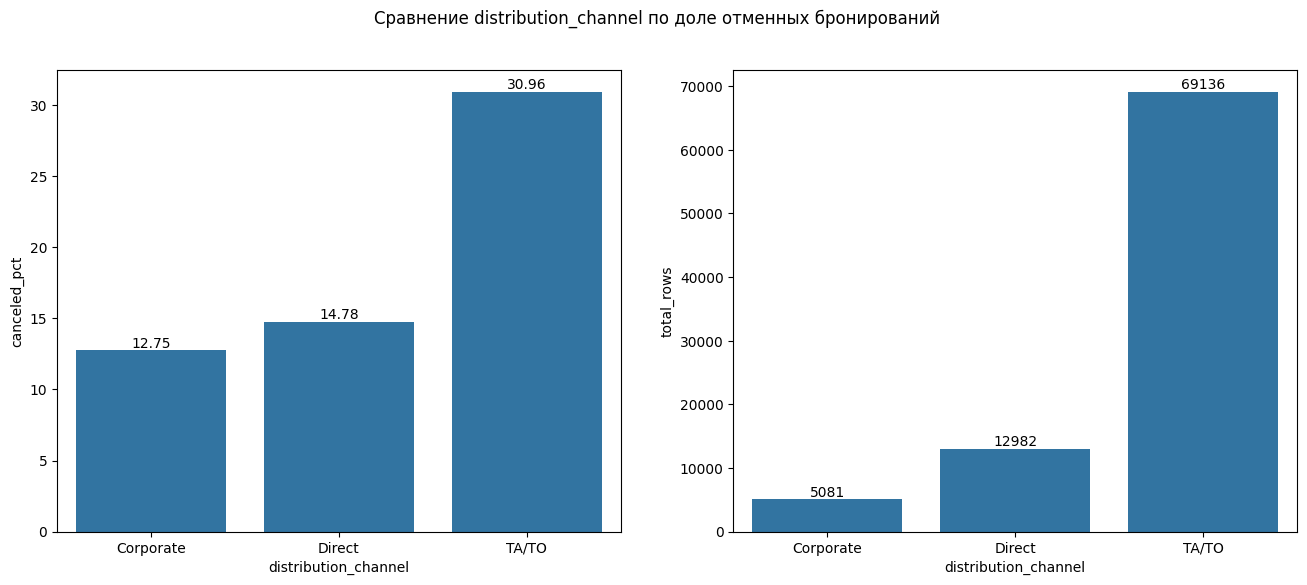

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение market_segment по доле отменных бронирований')

sns.barplot(market_segments['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(market_segments['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle('Сравнение distribution_channel по доле отменных бронирований')

sns.barplot(distribution_channels['canceled_pct'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0])

sns.barplot(distribution_channels['total_rows'], ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
plt.show()

Действительно, у Corporate ниже доля отмен, вот как раз таки у TA/TO сильно выше, но пока статистически это не подтверждено.

Теперь давайте закрепим наше первичное представление о причина успеха Solo и вернемся к графикам с прошлой части анализа но посмотрим все только без Corporate, то есть попробуем так уровнять Solo с другими категориями гостей.

Для начала все используемые датафреймы отфильтруем по новому условию

In [249]:
df_without_corp = df[(df['market_segment'] != 'Corporate') & (df['distribution_channel'] != 'Corporate')]
city_hotel_canceled_cnt = round(df_without_corp[(df_without_corp['hotel'] == 'City Hotel') & (df_without_corp['is_canceled'] == 1)].shape[0] / df_without_corp[df_without_corp['hotel'] == 'City Hotel'].shape[0] * 100, 2)
resort_hotel_canceled_cnt = round(df_without_corp[(df_without_corp['hotel'] == 'Resort Hotel') & (df_without_corp['is_canceled'] == 1)].shape[0] / df_without_corp[df_without_corp['hotel'] == 'Resort Hotel'].shape[0] * 100, 2)

guests_categories = df_without_corp.groupby(['guests_categories', 'hotel']).agg(total_canceled = ('is_canceled', 'sum'), total_rows= ('is_canceled', 'size'))

guests_categories['canceled_pct'] = round(guests_categories['total_canceled'] / guests_categories['total_rows'] * 100, 2)
guests_categories = guests_categories.sort_values('canceled_pct', ascending=False)

hotels_value_counts = df_without_corp['hotel'].value_counts().reset_index().T
# https://datascientyst.com/how-to-use-the-first-row-as-the-header-in-pandas/
hotels_value_counts.columns = hotels_value_counts.iloc[0]
hotels_value_counts = hotels_value_counts[1:]

In [250]:
df_without_corp

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,guests_categories,stays_in_nights,has_weekend_nights
0,Resort Hotel,0,342,2015,July,27,1,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,Couple,0,0
1,Resort Hotel,0,737,2015,July,27,1,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,Couple,0,0
2,Resort Hotel,0,7,2015,July,27,1,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,Solo,1,0
4,Resort Hotel,0,14,2015,July,27,1,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,Couple,2,0
6,Resort Hotel,0,0,2015,July,27,1,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03,Couple,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06,Couple,7,1
119386,City Hotel,0,102,2017,August,35,31,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07,Group,7,1
119387,City Hotel,0,34,2017,August,35,31,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07,Couple,7,1
119388,City Hotel,0,109,2017,August,35,31,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07,Couple,7,1


А далее построим тот же график.

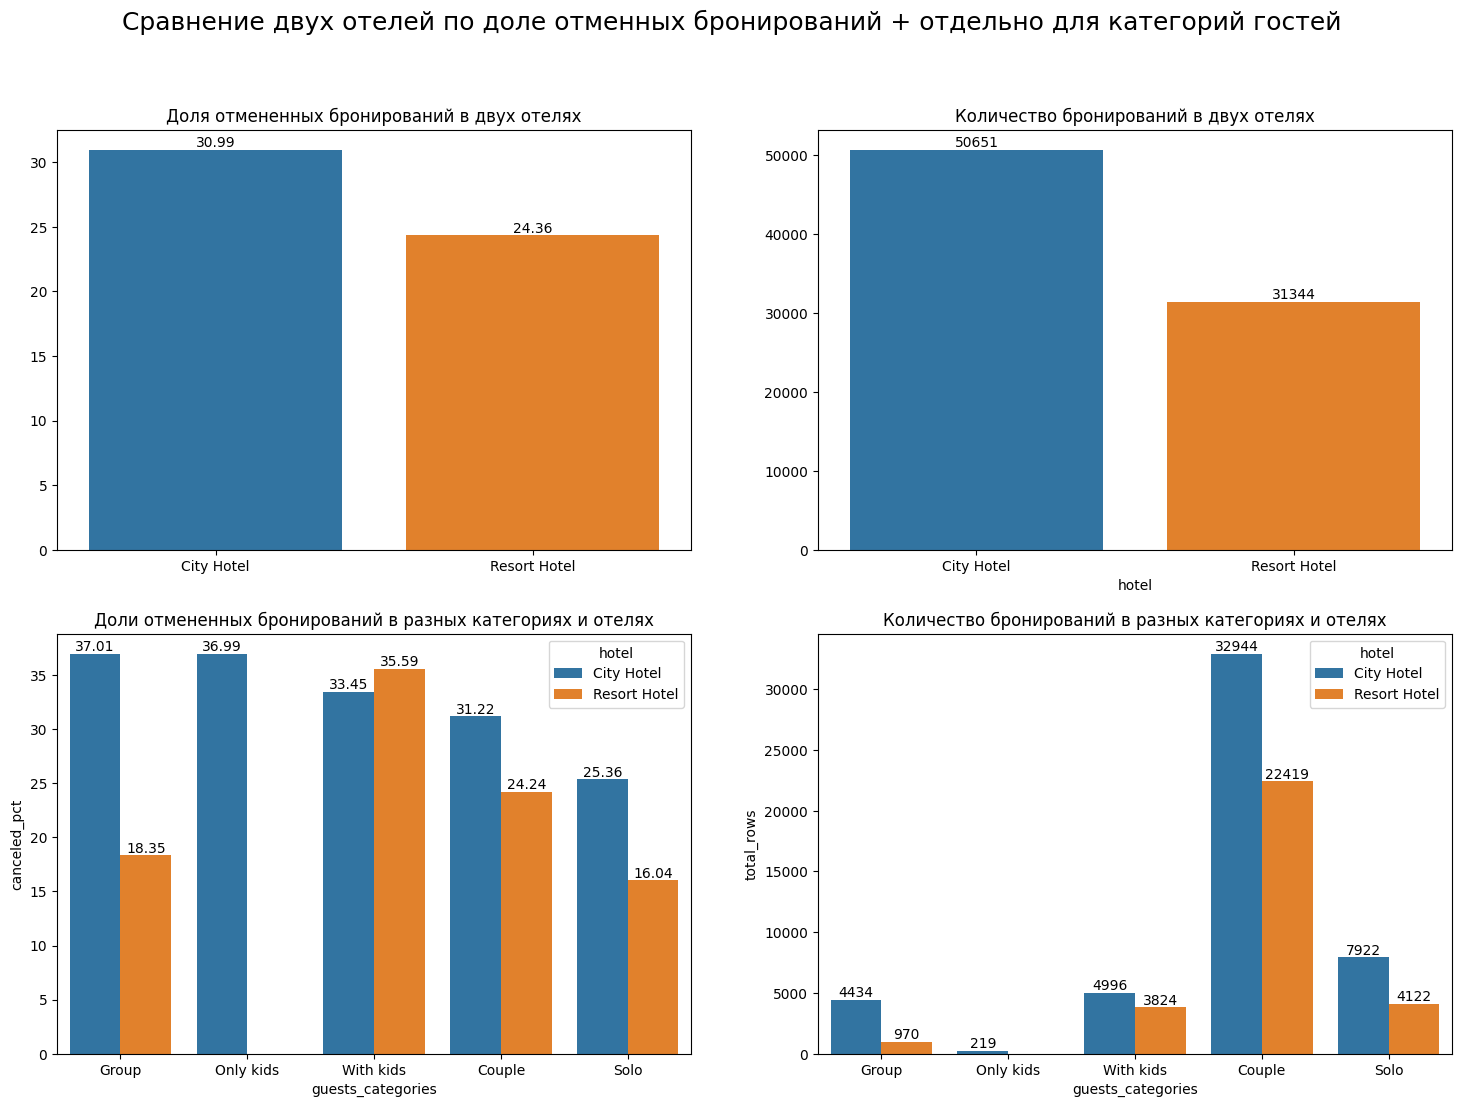

In [251]:


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle('Сравнение двух отелей по доле отменных бронирований + отдельно для категорий гостей', fontsize='18')

# https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot + добавили объектный подход построения нескольких графиков на полотне

sns.barplot(pd.DataFrame({'City Hotel': [city_hotel_canceled_cnt], 'Resort Hotel': [resort_hotel_canceled_cnt]}), ax=axes[0, 0])
axes[0, 0].set_title('Доля отмененных бронирований в двух отелях')
axes[0, 0].bar_label(axes[0, 0].containers[0])
axes[0, 0].bar_label(axes[0, 0].containers[1])

sns.barplot(hotels_value_counts, ax=axes[0, 1])
axes[0, 1].set_title('Количество бронирований в двух отелях')
axes[0, 1].bar_label(axes[0, 1].containers[0])
axes[0, 1].bar_label(axes[0, 1].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='canceled_pct', hue='hotel', ax=axes[1, 0])
axes[1, 0].set_title('Доли отмененных бронирований в разных категориях и отелях')
axes[1, 0].bar_label(axes[1, 0].containers[0])
axes[1, 0].bar_label(axes[1, 0].containers[1])

sns.barplot(guests_categories, x='guests_categories', y='total_rows', hue='hotel', ax=axes[1, 1])
axes[1, 1].set_title('Количество бронирований в разных категориях и отелях')
axes[1, 1].bar_label(axes[1, 1].containers[0])
axes[1, 1].bar_label(axes[1, 1].containers[1])
plt.show()

Вывыдем отдельно еще данные с прошлого графика:

In [254]:
print(f'Доля отмененных бронирований в Resort Hotel: 24.36% (23.46% - без Corporate)')
print(f'Доля отмененных бронирований в Resort Hotel для Solo: 16.04% (14.12% - без Corporate)\n')

print(f'Доля отмененных бронирований в City Hotel: 30.99% (30.04% - без Corporate)')
print(f'Доля отмененных бронирований в City Hotel для Solo: 25.36% (22.23% - без Corporate)')

Доля отмененных бронирований в Resort Hotel: 24.36% (23.46% - без Corporate)
Доля отмененных бронирований в Resort Hotel для Solo: 16.04% (14.12% - без Corporate)

Доля отмененных бронирований в City Hotel: 30.99% (30.04% - без Corporate)
Доля отмененных бронирований в City Hotel для Solo: 25.36% (22.23% - без Corporate)


В Resort Hotel с новым фильтром доля отменных бронирований выросла, но также произошла и для City Hotel, так что на первый взгляд говорить, что Corporate "завышвает" результаты для Resort Hotel нельзя, но можно сказать, что сказывается отдельно на категории Solo, хотя даже так она сильно лучше остальных, о чем мы говорили по прошлому графику